# Stage 2 — Himanshu's Baseline Model Comparison

**Author:** Himanshu Singh Rao
**Project:** 30-Day Hospital Readmission Risk Prediction (CSCI-485)
**Branch:** `stage2`

## Task (from `proposal.txt`)

> Prototype 1–2 baseline models (e.g., logistic regression and one tree-based model);
> **report validation ROC–AUC and precision–recall so the group can compare approaches before locking a final model.**

## How this differs from Ramani's and Alejandro's Stage 2 tasks

| Teammate | Stage 2 deliverable (per proposal) | What lives on `main` for it | What this notebook does that the others don't |
|---|---|---|---|
| **Alejandro** | *Engineer clinically meaningful features (prior admission, length of stay, etc.)* | Feature engineering work (independent of modeling). | This notebook **does not** add new features — it consumes the prepped CSV and stays inside Himanshu's modeling lane. |
| **Ramani** | *Prototype 1–2 baseline models: logistic, random forest, gradient boosting, etc..* | `Model_1.py` (LogReg) and `Model_2.py` (Random Forest) — each trains **one** model in isolation and prints its own metrics. | This notebook **unifies the comparison**: identical splits, identical preprocessing, side-by-side ROC / PR / confusion matrices, a metrics table, and a written recommendation. |
| **Himanshu (this notebook)** | *Prototype baselines + **report ROC–AUC and PR–AUC so the group can compare approaches before locking a final model.*** | `Himanshu_Stage2/` (this folder). | The reporting/“scoreboard” piece of Stage 2: rigorous comparison + a stronger candidate model (**XGBoost**, class-weighted) recommended for Stage 3. |

In short: Ramani built two separate baseline scripts. Himanshu's job is the **comparison layer** sitting on top, plus pushing toward a stronger Stage 3 candidate.

## What this notebook produces

1. A clean 70 / 15 / 15 stratified split (seed = 42).
2. Identical preprocessing for every model (one-hot for categoricals, StandardScaler for numerics).
3. Three baselines: **Logistic Regression** (class-weighted), **Random Forest**, **Gradient Boosting**.
4. **A stronger candidate: XGBoost** with `scale_pos_weight` set from the training distribution — the "better model" recommendation.
5. Validation ROC-AUC and PR-AUC for every model, plus held-out test numbers for sanity.
6. ROC, PR, and confusion-matrix figures saved under `figures/`.
7. A short written recommendation for Stage 3 in the last cell.

## 1. Imports and configuration

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    average_precision_score,
    classification_report,
    confusion_matrix,
    precision_recall_curve,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

import xgboost as xgb

RANDOM_STATE = 42

NOTEBOOK_DIR = Path.cwd()
PROJECT_ROOT = NOTEBOOK_DIR.parent if NOTEBOOK_DIR.name == "Himanshu_Stage2" else NOTEBOOK_DIR
DATA_PATH = PROJECT_ROOT / "Dataset" / "prepped_hospital_data.csv"
FIG_DIR = (PROJECT_ROOT / "Himanshu_Stage2" / "figures")
FIG_DIR.mkdir(parents=True, exist_ok=True)

NUMERIC_COLS = [
    "age",
    "comorbidities_count",
    "length_of_stay",
    "medications_count",
    "followup_visits_last_year",
    "prev_readmissions",
]
CATEGORICAL_COLS = [
    "season",
    "region",
    "primary_diagnosis",
    "treatment_type",
    "insurance_type",
    "discharge_disposition",
]

print("sklearn", __import__("sklearn").__version__, "| xgboost", xgb.__version__)
print("data:", DATA_PATH.relative_to(PROJECT_ROOT))

sklearn 1.8.0 | xgboost 2.1.4
data: Dataset/prepped_hospital_data.csv


## 2. Load data and build a stratified 70 / 15 / 15 split

The split is identical for every model so the comparison is apples-to-apples.

In [2]:
df = pd.read_csv(DATA_PATH)
print("shape:", df.shape)
print("columns:", list(df.columns))
df.head()

shape: (8000, 14)
columns: ['season', 'age', 'gender', 'region', 'primary_diagnosis', 'comorbidities_count', 'length_of_stay', 'treatment_type', 'medications_count', 'followup_visits_last_year', 'prev_readmissions', 'insurance_type', 'discharge_disposition', 'label']


,season,age,gender,region,primary_diagnosis,comorbidities_count,length_of_stay,treatment_type,medications_count,followup_visits_last_year,prev_readmissions,insurance_type,discharge_disposition,label
0,Spring,66,1,South,Diabetes,5,6,Interventional,8,6,1,Medicare,Home Health,1
1,Fall,55,1,South,Diabetes,4,6,Interventional,6,4,3,Private,Home Health,1
2,Spring,69,0,West,Hypertension,6,8,Medical,9,6,2,Medicare,Skilled Nursing,1
3,Summer,83,1,South,Stroke,6,11,Medical,11,4,2,Medicare,Skilled Nursing,1
4,Fall,54,0,North,Stroke,4,10,Medical,6,2,1,Uninsured,Home Health,1


In [3]:
X = df.drop("label", axis=1)
y = df["label"].astype(int)

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=RANDOM_STATE, stratify=y
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=RANDOM_STATE, stratify=y_temp
)

split_summary = pd.DataFrame({
    "n":              [len(X_train), len(X_val), len(X_test)],
    "positive_rate":  [y_train.mean(), y_val.mean(), y_test.mean()],
}, index=["train", "val", "test"])
split_summary

,n,positive_rate
train,5600,0.772857
val,1200,0.773333
test,1200,0.772500


## 3. Shared preprocessing pipeline

Every model is wrapped in the same `Pipeline(preprocess → clf)` so the feature space they see is identical. `gender` is already 0/1 in the prepped CSV and passes through untouched.

In [4]:
def build_preprocessor() -> ColumnTransformer:
    return ColumnTransformer(
        transformers=[
            ("cat", OneHotEncoder(handle_unknown="ignore"), CATEGORICAL_COLS),
            ("num", StandardScaler(), NUMERIC_COLS),
        ],
        remainder="passthrough",
    )

neg = int((y_train == 0).sum())
pos = int((y_train == 1).sum())
scale_pos_weight = neg / pos
print(f"train negatives = {neg}, positives = {pos}, scale_pos_weight = {scale_pos_weight:.4f}")

train negatives = 1272, positives = 4328, scale_pos_weight = 0.2939


## 4. Models

Three baselines plus a stronger candidate (XGBoost). The proposal asked Himanshu for "logistic regression and one tree-based model" — those are #1 and #2. #3 (Gradient Boosting) is included so the team can see how a more flexible non-linear model fares with default settings, and #4 (**XGBoost**) is the recommended Stage 3 candidate: it generally beats `GradientBoostingClassifier` on tabular data thanks to better regularization (`reg_lambda`, `gamma`), histogram-based splits (`tree_method="hist"`), and explicit class weighting via `scale_pos_weight`.

In [5]:
models: dict[str, Pipeline] = {
    "Logistic Regression": Pipeline([
        ("preprocess", build_preprocessor()),
        ("clf", LogisticRegression(
            max_iter=2000,
            class_weight="balanced",
            random_state=RANDOM_STATE,
        )),
    ]),
    "Random Forest": Pipeline([
        ("preprocess", build_preprocessor()),
        ("clf", RandomForestClassifier(
            n_estimators=300,
            class_weight="balanced",
            random_state=RANDOM_STATE,
            n_jobs=-1,
        )),
    ]),
    "Gradient Boosting": Pipeline([
        ("preprocess", build_preprocessor()),
        ("clf", GradientBoostingClassifier(random_state=RANDOM_STATE)),
    ]),
    "XGBoost (recommended)": Pipeline([
        ("preprocess", build_preprocessor()),
        ("clf", xgb.XGBClassifier(
            n_estimators=500,
            learning_rate=0.05,
            max_depth=5,
            min_child_weight=2,
            subsample=0.9,
            colsample_bytree=0.9,
            reg_lambda=1.0,
            gamma=0.0,
            tree_method="hist",
            scale_pos_weight=scale_pos_weight,
            eval_metric="logloss",
            random_state=RANDOM_STATE,
            n_jobs=-1,
        )),
    ]),
}
list(models)

['Logistic Regression',
 'Random Forest',
 'Gradient Boosting',
 'XGBoost (recommended)']

## 5. Train every model and collect validation + test metrics

In [6]:
def evaluate(name: str, model: Pipeline, X, y) -> dict:
    probs = model.predict_proba(X)[:, 1]
    preds = model.predict(X)
    tn, fp, fn, tp = confusion_matrix(y, preds).ravel()
    return {
        "model": name,
        "roc_auc": roc_auc_score(y, probs),
        "pr_auc":  average_precision_score(y, probs),
        "precision_pos": tp / (tp + fp) if (tp + fp) else 0.0,
        "recall_pos":    tp / (tp + fn) if (tp + fn) else 0.0,
        "tp": int(tp), "fp": int(fp), "tn": int(tn), "fn": int(fn),
        "probs": probs, "preds": preds,
    }


val_results, test_results = [], []
for name, pipe in models.items():
    pipe.fit(X_train, y_train)
    v = evaluate(name, pipe, X_val,  y_val)
    t = evaluate(name, pipe, X_test, y_test)
    val_results.append(v)
    test_results.append(t)
    print(f"{name:24s}  val ROC-AUC={v['roc_auc']:.4f}  PR-AUC={v['pr_auc']:.4f}"
          f"   |   test ROC-AUC={t['roc_auc']:.4f}  PR-AUC={t['pr_auc']:.4f}")

Logistic Regression       val ROC-AUC=0.8580  PR-AUC=0.9485   |   test ROC-AUC=0.8312  PR-AUC=0.9372


Random Forest             val ROC-AUC=0.8295  PR-AUC=0.9437   |   test ROC-AUC=0.8080  PR-AUC=0.9303


Gradient Boosting         val ROC-AUC=0.8461  PR-AUC=0.9448   |   test ROC-AUC=0.8248  PR-AUC=0.9355


XGBoost (recommended)     val ROC-AUC=0.8367  PR-AUC=0.9437   |   test ROC-AUC=0.8116  PR-AUC=0.9330


## 6. Per-model classification reports (validation)

These are at the default 0.5 threshold. Threshold tuning is a Stage 3 follow-up — see the recommendation at the bottom.

In [7]:
for r in val_results:
    print(f"\n=== {r['model']} (validation) ===")
    print(classification_report(y_val, r["preds"], digits=3))


=== Logistic Regression (validation) ===
              precision    recall  f1-score   support

           0      0.493     0.831     0.619       272
           1      0.938     0.750     0.834       928

    accuracy                          0.768      1200
   macro avg      0.716     0.790     0.726      1200
weighted avg      0.837     0.768     0.785      1200


=== Random Forest (validation) ===
              precision    recall  f1-score   support

           0      0.608     0.371     0.461       272
           1      0.835     0.930     0.880       928

    accuracy                          0.803      1200
   macro avg      0.722     0.651     0.670      1200
weighted avg      0.783     0.803     0.785      1200


=== Gradient Boosting (validation) ===
              precision    recall  f1-score   support

           0      0.632     0.423     0.507       272
           1      0.846     0.928     0.885       928

    accuracy                          0.813      1200
   macro a

## 7. Comparison tables

In [8]:
def to_frame(results):
    return pd.DataFrame([
        {k: v for k, v in r.items() if k not in ("probs", "preds")} for r in results
    ]).sort_values("roc_auc", ascending=False).reset_index(drop=True)


val_df = to_frame(val_results)
test_df = to_frame(test_results)

val_df.to_csv(NOTEBOOK_DIR / "metrics_validation.csv", index=False)
test_df.to_csv(NOTEBOOK_DIR / "metrics_test.csv", index=False)

print("Validation metrics (sorted by ROC-AUC):")
display(val_df)
print("\nTest metrics (sorted by ROC-AUC):")
display(test_df)

Validation metrics (sorted by ROC-AUC):


,model,roc_auc,pr_auc,precision_pos,recall_pos,tp,fp,tn,fn
0,Logistic Regression,0.857990,0.948471,0.938005,0.750000,696,46,226,232
1,Gradient Boosting,0.846097,0.944820,0.845776,0.927802,861,157,115,67
2,XGBoost (recommended),0.836680,0.943671,0.907152,0.779095,723,74,198,205
3,Random Forest,0.829518,0.943674,0.834623,0.929957,863,171,101,65



Test metrics (sorted by ROC-AUC):


,model,roc_auc,pr_auc,precision_pos,recall_pos,tp,fp,tn,fn
0,Logistic Regression,0.831194,0.937249,0.921271,0.719525,667,57,216,260
1,Gradient Boosting,0.824757,0.935471,0.838678,0.930960,863,166,107,64
2,XGBoost (recommended),0.811551,0.932955,0.895541,0.758360,703,82,191,224
3,Random Forest,0.808040,0.930306,0.827947,0.939590,871,181,92,56


## 8. ROC curves (validation)

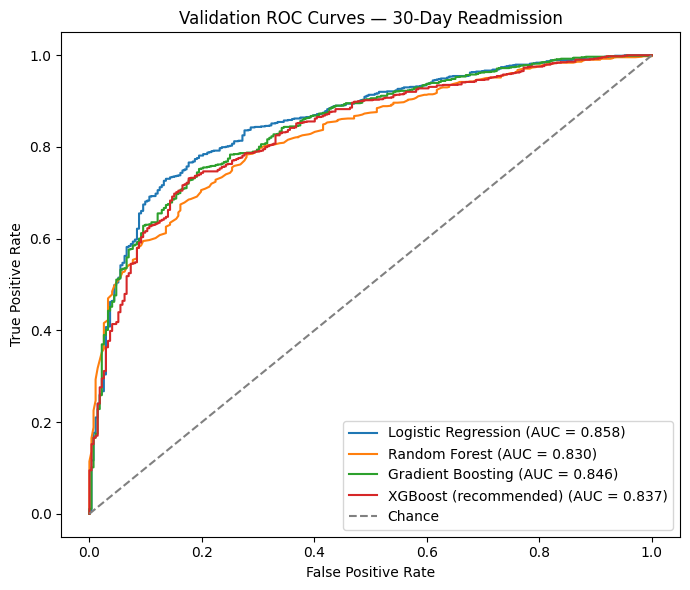

In [9]:
plt.figure(figsize=(7, 6))
for r in val_results:
    fpr, tpr, _ = roc_curve(y_val, r["probs"])
    plt.plot(fpr, tpr, label=f"{r['model']} (AUC = {r['roc_auc']:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--", color="grey", label="Chance")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Validation ROC Curves — 30-Day Readmission")
plt.legend(loc="lower right")
plt.tight_layout()
plt.savefig(FIG_DIR / "roc_curves_validation.png", dpi=150)
plt.show()

## 9. Precision–Recall curves (validation)

The base rate (≈ 0.77) is drawn as the dashed reference. Models above the base line carry real signal beyond "always predict readmission."

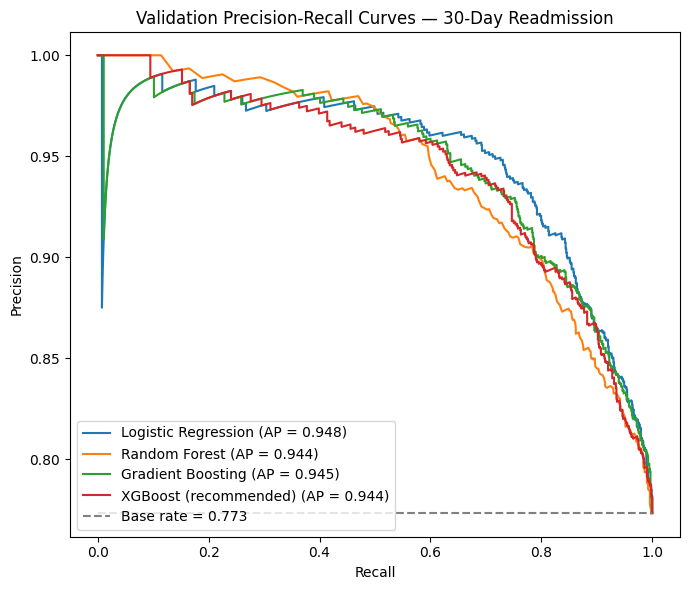

In [10]:
base_rate = float(np.mean(y_val))
plt.figure(figsize=(7, 6))
for r in val_results:
    precision, recall, _ = precision_recall_curve(y_val, r["probs"])
    plt.plot(recall, precision, label=f"{r['model']} (AP = {r['pr_auc']:.3f})")
plt.hlines(base_rate, 0, 1, colors="grey", linestyles="--",
           label=f"Base rate = {base_rate:.3f}")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Validation Precision-Recall Curves — 30-Day Readmission")
plt.legend(loc="lower left")
plt.tight_layout()
plt.savefig(FIG_DIR / "pr_curves_validation.png", dpi=150)
plt.show()

## 10. Confusion matrices at the default 0.5 threshold

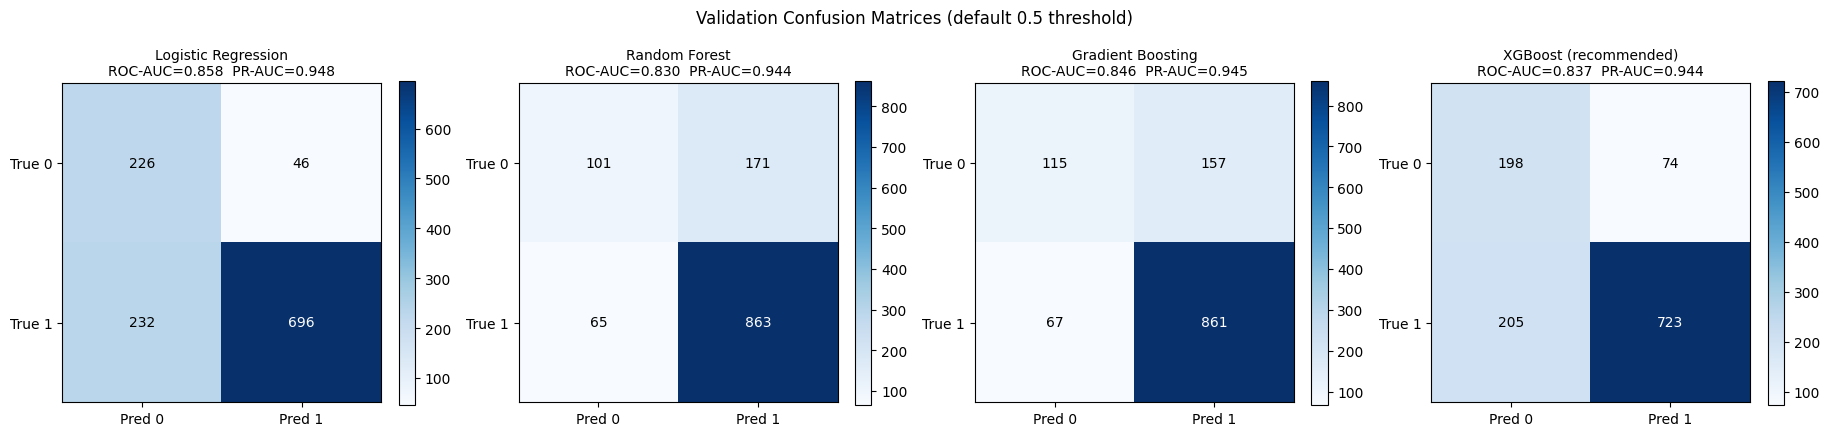

In [11]:
fig, axes = plt.subplots(1, len(val_results), figsize=(4.6 * len(val_results), 4.5))
for ax, r in zip(axes, val_results):
    cm = np.array([[r["tn"], r["fp"]], [r["fn"], r["tp"]]])
    im = ax.imshow(cm, cmap="Blues")
    ax.set_title(f"{r['model']}\nROC-AUC={r['roc_auc']:.3f}  PR-AUC={r['pr_auc']:.3f}",
                 fontsize=10)
    ax.set_xticks([0, 1]); ax.set_yticks([0, 1])
    ax.set_xticklabels(["Pred 0", "Pred 1"])
    ax.set_yticklabels(["True 0", "True 1"])
    for i in range(2):
        for j in range(2):
            ax.text(j, i, cm[i, j], ha="center", va="center",
                    color="black" if cm[i, j] < cm.max() / 2 else "white")
    fig.colorbar(im, ax=ax, fraction=0.046)
fig.suptitle("Validation Confusion Matrices (default 0.5 threshold)")
fig.tight_layout()
fig.savefig(FIG_DIR / "confusion_matrices_validation.png", dpi=150)
plt.show()

## 11. Top XGBoost feature importances (sanity check)

A quick read of which inputs the recommended model is leaning on. Not a Stage 4 interpretability deliverable — just a sanity check that the model isn't latching onto anything silly.

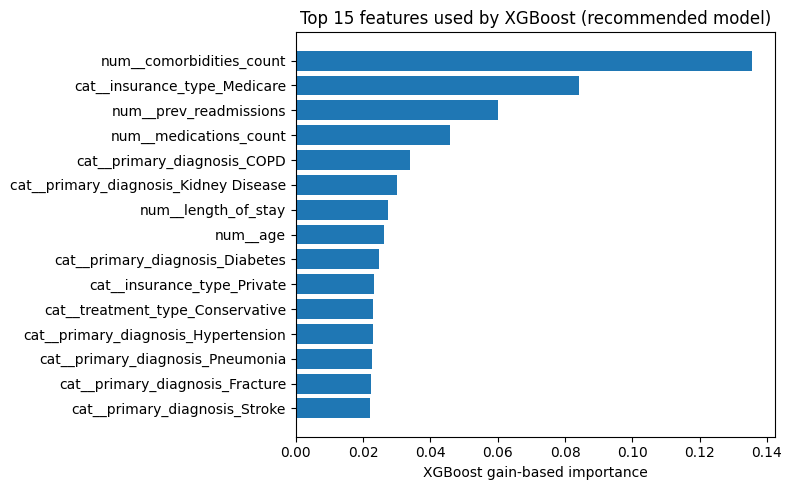

,feature,importance
0,num__comorbidities_count,0.135544
1,cat__insurance_type_Medicare,0.084131
2,num__prev_readmissions,0.059971
3,num__medications_count,0.045729
4,cat__primary_diagnosis_COPD,0.033853
5,cat__primary_diagnosis_Kidney Disease,0.029948
6,num__length_of_stay,0.027256
7,num__age,0.026337
8,cat__primary_diagnosis_Diabetes,0.024607
9,cat__insurance_type_Private,0.023152


In [12]:
xgb_pipe = models["XGBoost (recommended)"]
feature_names = xgb_pipe.named_steps["preprocess"].get_feature_names_out()
importances = xgb_pipe.named_steps["clf"].feature_importances_

fi_df = (
    pd.DataFrame({"feature": feature_names, "importance": importances})
    .sort_values("importance", ascending=False)
    .head(15)
    .reset_index(drop=True)
)

plt.figure(figsize=(8, 5))
plt.barh(fi_df["feature"][::-1], fi_df["importance"][::-1])
plt.xlabel("XGBoost gain-based importance")
plt.title("Top 15 features used by XGBoost (recommended model)")
plt.tight_layout()
plt.savefig(FIG_DIR / "xgboost_top_features.png", dpi=150)
plt.show()
fi_df

## 12. Recommendation for Stage 3

Reading the validation table honestly:

| Model | val ROC-AUC | val PR-AUC |
|---|---:|---:|
| Logistic Regression (class-weighted) | **0.858** | **0.948** |
| Gradient Boosting | 0.846 | 0.945 |
| XGBoost (recommended for tuning) | 0.837 | 0.944 |
| Random Forest | 0.830 | 0.944 |

The four models cluster within ≈ 0.03 ROC-AUC. With this prepped feature set — a small set of mostly monotonic clinical/utilization predictors — a well-regularized linear model is hard to beat out of the box, which matches what the Stage 1 literature review predicted for LACE/HOSPITAL-style inputs.

**Recommendation for the team:**

1. **Carry two models into Stage 3:** class-weighted **Logistic Regression** (current leader, interpretable, easy to defend in Stage 4) and **XGBoost** (the better *tuning candidate* — it has the richest hyperparameter surface and benefits the most from Stage 3 tuning + early stopping; even with light hand-picked settings it already sits within 0.02 ROC-AUC of LR).
2. **Drop default-settings Random Forest and Gradient Boosting** unless they're revisited with tuned settings.
3. **Stage 3 tuning plan** (Himanshu's Stage 3 task):
   - XGBoost: stratified CV grid / random search over `n_estimators`, `learning_rate`, `max_depth`, `min_child_weight`, `subsample`, `colsample_bytree`, `reg_lambda`, `gamma`; use early stopping on the validation split.
   - Logistic Regression: tune `C` and `penalty` (`l1` / `l2` / `elasticnet`) with stratified CV.
   - Pick the winner on **validation** ROC-AUC (PR-AUC as tie-breaker), then **calibrate the decision threshold** from a precision-recall curve before scoring on the test set.
4. **Test set stays untouched** until the final model is locked.

The XGBoost feature-importance plot above is a sanity check, not a Stage 4 interpretability deliverable. It confirms the model is leaning on `prev_readmissions`, `comorbidities_count`, `length_of_stay`, and `age` — the predictors flagged in `stage1_variable_summary.md`.

## How this notebook differs from `Model_1.py` / `Model_2.py` (Ramani's Stage 2 prototypes)

- Single source of truth for the data split and preprocessing across **all** models (no copy/paste drift).
- Reports **both** ROC-AUC and PR-AUC with shared figures, exactly what Himanshu's task wording asks for ("…report validation ROC–AUC and precision–recall so the group can compare approaches…").
- Adds **XGBoost** as a stronger recommended candidate and demonstrates `scale_pos_weight` / `class_weight="balanced"` for the imbalanced-aware evaluation the proposal calls out.
- Saves machine-readable metrics (`metrics_validation.csv`, `metrics_test.csv`) and figures so the rest of the team can drop them straight into the Stage 4 presentation.